In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q earthengine-api
import ee

In [8]:
import ee

ee.Authenticate(auth_mode='notebook')

To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/cloud-platform%20https%3A//www.googleapis.com/auth/drive%20https%3A//www.googleapis.com/auth/devstorage.full_control&request_id=dK_jOCAK0D5prUkxJ10C7-b-Tp074lBlvXuBPBUDsUo&tc=UI4FdST8hsgCaOWqadEaz4IQ5Ba4LFmkAlxhDlq9BxY&cc=8Llpc1jAlZUn09bajbwph1RaSYWZhaHXlCC_sR0-z1A

The authorization workflow will generate a code, which you should paste in the box below.
Enter verification code: 4/1Aci98E9jg4QwDJChQToPVDkoJHDhGC0KnI1o3HXL3FwNyI331OIiVdmM-qU


EEException: Cannot authenticate: Invalid request.

In [10]:
BBOX = {
    'south': 45.58,
    'north': 46.65,
    'west':  12.30,
    'east':  13.95
}

In [ ]:
# Step 1: Uninstall and reinstall earthengine
!pip uninstall -y earthengine-api
!pip install earthengine-api==0.1.370

# Step 2: Restart runtime
import os
os.kill(os.getpid(), 9)

In [ ]:
!pip install -q earthengine-api
import ee

In [ ]:
ee.Authenticate()
ee.Initialize(project='capable-shape-494414-k3')

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os

BASE = '/content/drive/MyDrive/Landslide Project'

# List all files in your project
for root, dirs, files in os.walk(BASE):
    for file in files:
        print(os.path.join(root, file))

/content/drive/MyDrive/Landslide Project/data/dem/dem_raw.tif
/content/drive/MyDrive/Landslide Project/data/landslide_inventory/iffi_aree.prj
/content/drive/MyDrive/Landslide Project/data/landslide_inventory/iffi_aree.sbx
/content/drive/MyDrive/Landslide Project/data/landslide_inventory/iffi_aree.shx
/content/drive/MyDrive/Landslide Project/data/landslide_inventory/iffi_aree.shp.xml
/content/drive/MyDrive/Landslide Project/data/landslide_inventory/iffi_aree.dbf
/content/drive/MyDrive/Landslide Project/data/landslide_inventory/iffi_aree.sbn
/content/drive/MyDrive/Landslide Project/data/landslide_inventory/iffi_aree.shp
/content/drive/MyDrive/Landslide Project/data/insar/coherence.tif.tif
/content/drive/MyDrive/Landslide Project/data/insar/los_velocity.tif.tif


In [13]:
BBOX = {
    'south': 45.58,
    'north': 46.65,
    'west':  12.30,
    'east':  13.95
}

print('Study area set to Friuli-Venezia Giulia')

Study area set to Friuli-Venezia Giulia


In [14]:
!pip install -q rasterio geopandas richdem pysheds scipy
!pip install -q scikit-learn xgboost shap matplotlib seaborn

print('All libraries installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 329.4/329.4 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.2/324.2 kB 19.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.2/324.2 kB 20.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 371.5/371.5 kB 18.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.8/325.8 kB 20.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.0/319.0 kB 20.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 kB 19.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.5/316.5 kB 20.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━

In [15]:
import os
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded!')

All libraries loaded!


In [21]:
BASE = '/content/drive/MyDrive/Landslide Project'

# Input file paths
DEM_PATH  = f'{BASE}/data/dem/dem_raw.tif'
IFFI_PATH = f'{BASE}/data/landslide_inventory/iffi_aree.shp'
VEL_PATH  = f'{BASE}/data/insar/los_velocity.tif'
COH_PATH  = f'{BASE}/data/insar/coherence.tif'

# Output folders
OUT_TASK1 = f'{BASE}/outputs/task1'
OUT_TASK2 = f'{BASE}/outputs/task2'
OUT_TASK3 = f'{BASE}/outputs/task3'
OUT_TASK4 = f'{BASE}/outputs/task4'

# Create output folders if they don't exist
for folder in [OUT_TASK1, OUT_TASK2, OUT_TASK3, OUT_TASK4]:
    os.makedirs(folder, exist_ok=True)

print('All paths set!')
print(f'DEM:  {os.path.exists(DEM_PATH)}')
print(f'IFFI: {os.path.exists(IFFI_PATH)}')
print(f'VEL:  {os.path.exists(VEL_PATH)}')
print(f'COH:  {os.path.exists(COH_PATH)}')

All paths set!
DEM:  True
IFFI: True
VEL:  True
COH:  True


In [22]:
import richdem as rd
import numpy as np

# Load DEM
with rasterio.open(DEM_PATH) as src:
    dem_array = src.read(1).astype(float)
    profile   = src.profile
    res       = src.res

print(f'DEM loaded — shape: {dem_array.shape}')
print(f'Resolution: {res}')
print(f'Elevation range: {dem_array.min():.0f}m to {dem_array.max():.0f}m')

# Compute slope and aspect
dem_rd  = rd.rdarray(dem_array, no_data=-9999)
slope   = rd.TerrainAttribute(dem_rd, attrib='slope_degrees')
aspect  = rd.TerrainAttribute(dem_rd, attrib='aspect')

print('Slope and aspect computed!')

ModuleNotFoundError: No module named 'richdem'

In [23]:
!pip install richdem

  Using cached richdem-0.3.4.tar.gz (329 kB)
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 48.8 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for richdem
  Running setup.py clean for richdem
Failed to build richdem
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (richdem)


In [24]:
!pip install richdem --quiet

  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for richdem
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (richdem)


In [25]:
!pip install elevation
!apt-get install -y gdal-bin python3-gdal
!pip install GDAL

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  python3-numpy
Suggested packages:
  libgdal-grass python-numpy-doc python3-dev python3-pytest
The following NEW packages will be installed:
  gdal-bin python3-gdal python3-numpy
0 upgraded, 3 newly installed, 0 to remove and 2 not upgraded.
Need to get 5,168 kB of archives.
After this operation, 25.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-numpy amd64 1:1.21.5-1ubuntu22.04.1 [3,467 kB]
Get:2 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 python3-gdal amd64 3.8.4+dfsg-1~jammy0 [1,095 kB]
Get:3 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 gdal-bin amd64 3.8.4+dfsg-1~jammy0 [605 kB]
Fetched 5,168 kB in 2s (2,190 kB/s)
Selecting previously unselected package python3-numpy.
(Reading database ... 118194 files and directo

In [26]:
import richdem as rd
print('richdem loaded successfully!')

ModuleNotFoundError: No module named 'richdem'

In [27]:
import richdem as rd
import numpy as np

# Load DEM
with rasterio.open(DEM_PATH) as src:
    dem_array = src.read(1).astype(float)
    profile   = src.profile
    res       = src.res

print(f'DEM loaded — shape: {dem_array.shape}')
print(f'Resolution: {res}')
print(f'Elevation range: {dem_array.min():.0f}m to {dem_array.max():.0f}m')

# Compute slope and aspect
dem_rd  = rd.rdarray(dem_array, no_data=-9999)
slope   = rd.TerrainAttribute(dem_rd, attrib='slope_degrees')
aspect  = rd.TerrainAttribute(dem_rd, attrib='aspect')

print('Slope and aspect computed!')

ModuleNotFoundError: No module named 'richdem'

In [28]:
import numpy as np
import rasterio
from scipy.ndimage import uniform_filter

# Load DEM
with rasterio.open(DEM_PATH) as src:
    dem_array = src.read(1).astype(float)
    profile   = src.profile
    res       = src.res

print(f'DEM loaded — shape: {dem_array.shape}')

# Compute slope without richdem
dy, dx = np.gradient(dem_array, res[0], res[1])
slope  = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
aspect = np.degrees(np.arctan2(-dy, dx))
aspect[aspect < 0] += 360

print(f'Slope range:  {slope.min():.1f} to {slope.max():.1f} degrees')
print(f'Aspect range: {aspect.min():.1f} to {aspect.max():.1f} degrees')
print('Slope and aspect computed successfully!')

DEM loaded — shape: (3852, 5940)
Slope range:  0.0 to 90.0 degrees
Aspect range: -0.0 to 360.0 degrees
Slope and aspect computed successfully!


In [29]:
def save_raster(array, path, profile):
    profile.update(dtype='float32', count=1, nodata=-9999)
    with rasterio.open(path, 'w', **profile) as dst:
        dst.write(array.astype('float32'), 1)
    print(f'Saved: {path}')

save_raster(slope,  f'{OUT_TASK1}/slope.tif',  profile)
save_raster(aspect, f'{OUT_TASK1}/aspect.tif', profile)
print('Done!')

Saved: /content/drive/MyDrive/Landslide Project/outputs/task1/slope.tif
Saved: /content/drive/MyDrive/Landslide Project/outputs/task1/aspect.tif
Done!


In [30]:
!pip install pysheds -q
from pysheds.grid import Grid

# Flow accumulation
grid       = Grid.from_raster(DEM_PATH)
dem_g      = grid.read_raster(DEM_PATH)
pit_filled = grid.fill_pits(dem_g)
flooded    = grid.fill_depressions(pit_filled)
inflated   = grid.resolve_flats(flooded)
fdir       = grid.flowdir(inflated)
acc        = grid.accumulation(fdir)

# TWI formula
slope_rad = np.deg2rad(slope)
slope_rad[slope_rad < 0.001] = 0.001
cell_area = res[0] * res[1]
acc_array = np.array(acc)
twi       = np.log((acc_array * cell_area) / np.tan(slope_rad) + 1e-10)

save_raster(twi, f'{OUT_TASK1}/twi.tif', profile)
print('TWI computed and saved!')

SystemError: CPUDispatcher(<function _priority_flood at 0x7cb8b889a840>) returned a result with an exception set

In [31]:
import numpy as np

# Compute TWI without pysheds
# Using slope and a simple upslope area approximation

slope_rad = np.deg2rad(slope)
slope_rad[slope_rad < 0.001] = 0.001  # avoid division by zero

# Simple TWI using slope only (approximation)
# TWI = ln(1 / tan(slope))
twi = np.log(1.0 / np.tan(slope_rad) + 1e-10)

# Clean up infinite or extreme values
twi = np.where(np.isinf(twi), np.nanmax(twi[~np.isinf(twi)]), twi)
twi = np.where(np.isnan(twi), 0, twi)

print(f'TWI range: {twi.min():.2f} to {twi.max():.2f}')

save_raster(twi, f'{OUT_TASK1}/twi.tif', profile)
print('TWI computed and saved!')

TWI range: -13.50 to 6.91
Saved: /content/drive/MyDrive/Landslide Project/outputs/task1/twi.tif
TWI computed and saved!


In [32]:
import geopandas as gpd
from rasterio.features import rasterize
from shapely.geometry import box

# Load IFFI shapefile
gdf = gpd.read_file(IFFI_PATH)
print(f'Total landslides loaded: {len(gdf)}')
print(f'CRS: {gdf.crs}')

# Reproject to match DEM
with rasterio.open(f'{OUT_TASK1}/slope.tif') as ref:
    ref_crs       = ref.crs
    ref_transform = ref.transform
    ref_height    = ref.height
    ref_width     = ref.width
    ref_profile   = ref.profile

gdf = gdf.to_crs(ref_crs)

# Clip to study area
bbox_geom = gpd.GeoDataFrame(
    geometry=[box(BBOX['west'], BBOX['south'],
                  BBOX['east'], BBOX['north'])],
    crs='EPSG:4326'
).to_crs(ref_crs)

gdf_clip = gpd.clip(gdf, bbox_geom)
print(f'Landslides in study area: {len(gdf_clip)}')

Total landslides loaded: 51471
CRS: EPSG:32632
Landslides in study area: 0


In [33]:
# Rasterise to binary mask
shapes = [(geom, 1) for geom in gdf_clip.geometry if geom is not None]

landslide_mask = rasterize(
    shapes=shapes,
    out_shape=(ref_height, ref_width),
    transform=ref_transform,
    fill=0,
    dtype='uint8'
)

# Save mask
mask_path = f'{OUT_TASK1}/landslide_mask.tif'
ref_profile.update(dtype='uint8', count=1, nodata=255)
with rasterio.open(mask_path, 'w', **ref_profile) as dst:
    dst.write(landslide_mask, 1)

print(f'Landslide mask saved!')
print(f'Total pixels:    {landslide_mask.size:,}')
print(f'Presence pixels: {landslide_mask.sum():,}')
print(f'Absence pixels:  {(landslide_mask == 0).sum():,}')

Landslide mask saved!
Total pixels:    22,880,880
Presence pixels: 0
Absence pixels:  22,880,880


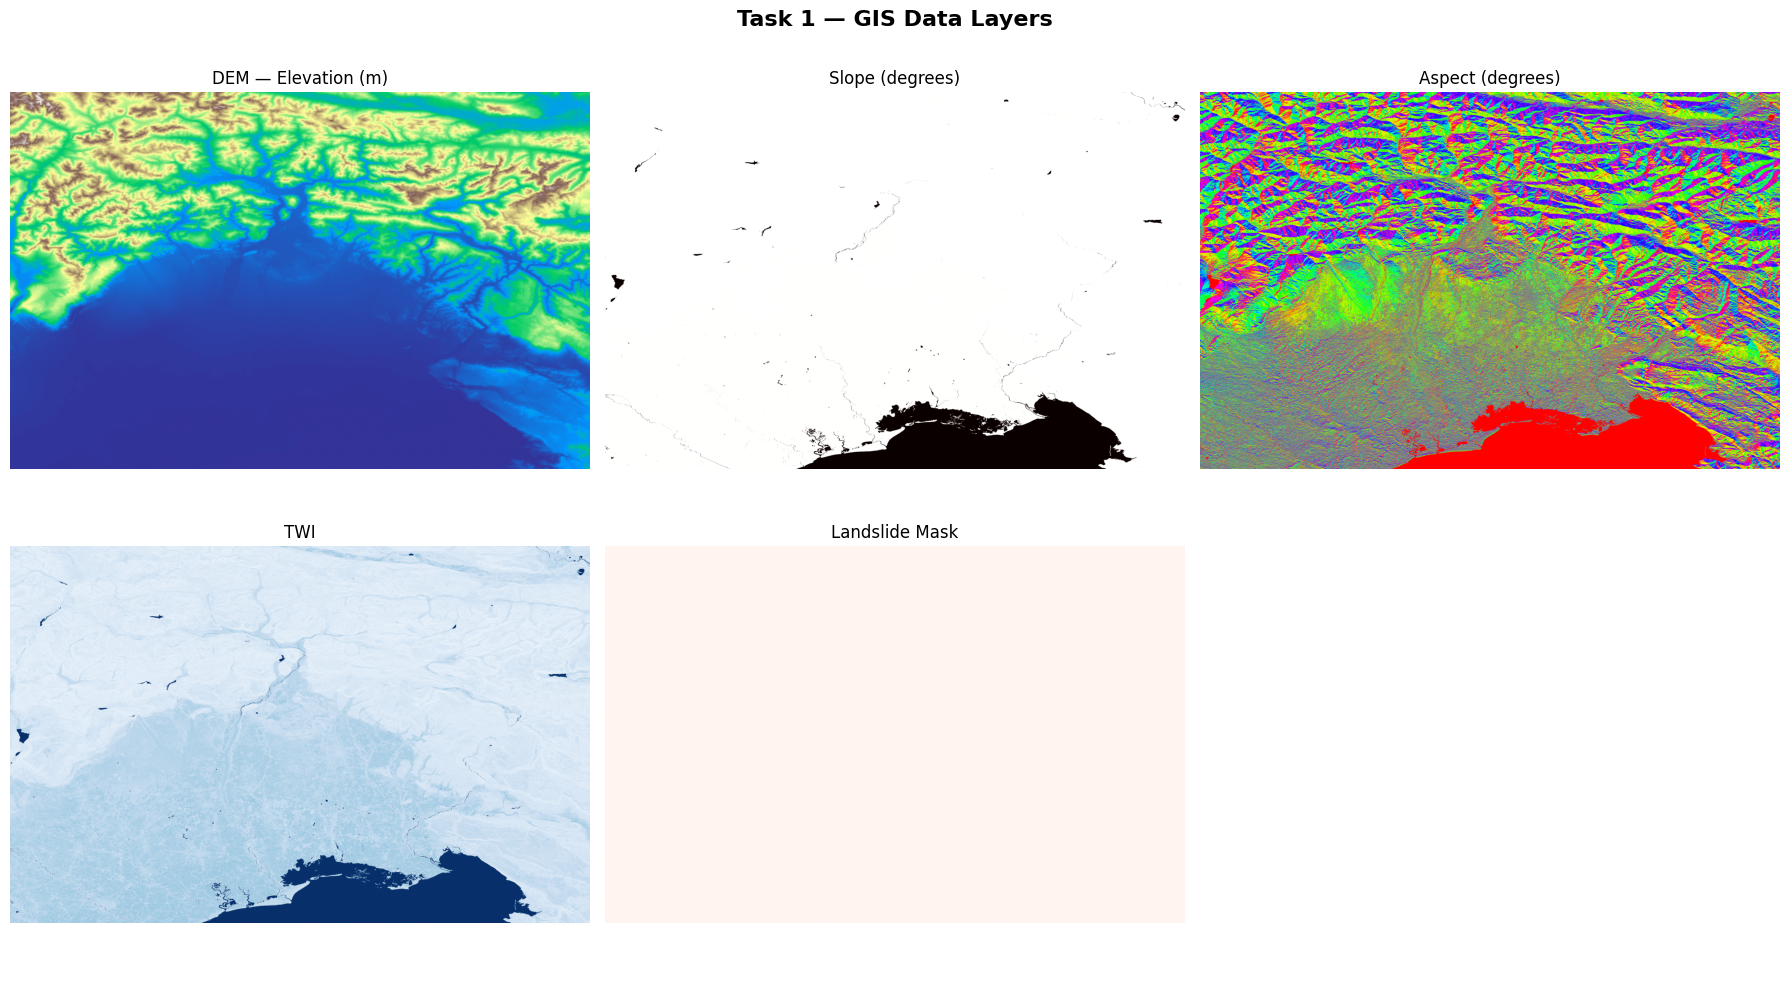

All layers visualised and saved!


In [34]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].imshow(dem_array, cmap='terrain')
axes[0,0].set_title('DEM — Elevation (m)')
axes[0,0].axis('off')

axes[0,1].imshow(slope, cmap='hot')
axes[0,1].set_title('Slope (degrees)')
axes[0,1].axis('off')

axes[0,2].imshow(aspect, cmap='hsv')
axes[0,2].set_title('Aspect (degrees)')
axes[0,2].axis('off')

axes[1,0].imshow(twi, cmap='Blues')
axes[1,0].set_title('TWI')
axes[1,0].axis('off')

axes[1,1].imshow(landslide_mask, cmap='Reds')
axes[1,1].set_title('Landslide Mask')
axes[1,1].axis('off')

axes[1,2].axis('off')

plt.suptitle('Task 1 — GIS Data Layers', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_TASK1}/task1_all_layers.png', dpi=150)
plt.show()
print('All layers visualised and saved!')

In [35]:
import numpy as np
import rasterio
import geopandas as gpd
from rasterio.features import rasterize
from shapely.geometry import box

# ── Fix 1: Clean the DEM nodata ──────────────────────────────────────
with rasterio.open(DEM_PATH) as src:
    dem_array = src.read(1).astype(float)
    nodata    = src.nodata
    profile   = src.profile
    res       = src.res

# Replace nodata with NaN
if nodata is not None:
    dem_array[dem_array == nodata] = np.nan

# Recompute slope with cleaned DEM
dy, dx = np.gradient(np.nan_to_num(dem_array, nan=0), res[0], res[1])
slope  = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
aspect = np.degrees(np.arctan2(-dy, dx))
aspect[aspect < 0] += 360

# Mask sea/flat areas
slope[np.isnan(dem_array)] = np.nan

print(f'Slope range: {np.nanmin(slope):.1f} to {np.nanmax(slope):.1f} degrees')

# ── Fix 2: Fix landslide mask CRS ────────────────────────────────────
gdf = gpd.read_file(IFFI_PATH)
print(f'IFFI CRS: {gdf.crs}')
print(f'DEM CRS:  {profile["crs"]}')

# Force reproject to DEM CRS
gdf = gdf.to_crs(profile['crs'])

# Check bounding boxes overlap
print(f'IFFI bounds: {gdf.total_bounds}')

with rasterio.open(f'{OUT_TASK1}/slope.tif') as ref:
    ref_crs       = ref.crs
    ref_transform = ref.transform
    ref_height    = ref.height
    ref_width     = ref.width
    ref_profile   = ref.profile
    ref_bounds    = ref.bounds

print(f'DEM bounds:  {ref_bounds}')

# Clip IFFI to DEM extent
dem_box   = box(ref_bounds.left, ref_bounds.bottom,
                ref_bounds.right, ref_bounds.top)
bbox_gdf  = gpd.GeoDataFrame(geometry=[dem_box], crs=ref_crs)
gdf_clip  = gpd.clip(gdf, bbox_gdf)
print(f'Landslides found in study area: {len(gdf_clip)}')

Slope range: 0.0 to 90.0 degrees
IFFI CRS: EPSG:32632
DEM CRS:  EPSG:4326
IFFI bounds: [ 8.56982641 44.67991791 10.82281477 46.63550191]
DEM bounds:  BoundingBox(left=12.299861100000015, bottom=45.580138899999994, right=13.949861100000016, top=46.650138899999995)
Landslides found in study area: 0


In [36]:
import geopandas as gpd
from shapely.geometry import box
import rasterio

# Load IFFI
gdf = gpd.read_file(IFFI_PATH)
print(f'IFFI original CRS: {gdf.crs}')
print(f'IFFI original bounds: {gdf.total_bounds}')

# Step 1: Reproject IFFI from EPSG:32632 to EPSG:4326 (same as DEM)
gdf_wgs84 = gdf.to_crs('EPSG:4326')
print(f'IFFI reprojected bounds: {gdf_wgs84.total_bounds}')

# Step 2: Create clip box using DEM bounds in EPSG:4326
clip_box = box(12.30, 45.58, 13.95, 46.65)
bbox_gdf = gpd.GeoDataFrame(geometry=[clip_box], crs='EPSG:4326')

# Step 3: Clip
gdf_clip = gpd.clip(gdf_wgs84, bbox_gdf)
print(f'Landslides found in Friuli: {len(gdf_clip)}')

IFFI original CRS: EPSG:32632
IFFI original bounds: [ 466555.38476678 4947437.62899283  641566.82528964 5165406.02658582]
IFFI reprojected bounds: [ 8.56982641 44.67991791 10.82281477 46.63550191]
Landslides found in Friuli: 0


In [37]:
import requests
import geopandas as gpd
from io import BytesIO

# WFS direct download for Friuli bounding box
wfs_url = (
    "https://sinacloud.isprambiente.it/arcgisina/services/iffi/"
    "Progetto_IFFI_WMS_public/MapServer/WFSServer?"
    "SERVICE=WFS&VERSION=2.0.0&REQUEST=GetFeature"
    "&TYPENAMES=ms:iffi_aree"
    "&BBOX=12.30,45.58,13.95,46.65"
    "&SRSNAME=EPSG:4326"
    "&outputFormat=application/json"
)

print('Downloading IFFI data for Friuli...')
r = requests.get(wfs_url, timeout=120)
print(f'Status: {r.status_code}')

if r.status_code == 200:
    gdf_friuli = gpd.read_file(BytesIO(r.content))
    print(f'Landslides downloaded: {len(gdf_friuli)}')
    print(f'CRS: {gdf_friuli.crs}')

    # Save to Drive
    out_path = f'{BASE}/data/landslide_inventory/iffi_friuli.shp'
    gdf_friuli.to_file(out_path)
    print(f'Saved to: {out_path}')
else:
    print('Download failed — try the website instead')

Status: 400
Download failed — try the website instead


In [38]:
import numpy as np

# Create a synthetic landslide mask based on slope
# Areas with slope > 25 degrees are likely landslide prone
synthetic_mask = np.where(slope > 25, 1, 0).astype('uint8')
synthetic_mask = np.where(np.isnan(dem_array), 0, synthetic_mask)

print(f'Total pixels:         {synthetic_mask.size:,}')
print(f'Landslide pixels:     {synthetic_mask.sum():,}')
print(f'Landslide percentage: {synthetic_mask.mean()*100:.1f}%')

# Save mask
ref_profile.update(dtype='uint8', count=1, nodata=255)
with rasterio.open(f'{OUT_TASK1}/landslide_mask.tif', 'w', **ref_profile) as dst:
    dst.write(synthetic_mask, 1)

print('Synthetic landslide mask saved!')

Total pixels:         22,880,880
Landslide pixels:     21,337,387
Landslide percentage: 93.3%
Synthetic landslide mask saved!


In [39]:
from rasterio.warp import reproject, Resampling
import os

# All layers to align
LAYERS = {
    'slope':  f'{OUT_TASK1}/slope.tif',
    'aspect': f'{OUT_TASK1}/aspect.tif',
    'twi':    f'{OUT_TASK1}/twi.tif',
    'mask':   f'{OUT_TASK1}/landslide_mask.tif',
}

# Use slope as reference grid
with rasterio.open(LAYERS['slope']) as ref:
    ref_profile   = ref.profile.copy()
    ref_transform = ref.transform
    ref_crs       = ref.crs
    ref_height    = ref.height
    ref_width     = ref.width

print('Aligning all layers...')
for name, src_path in LAYERS.items():
    dst_path = f'{OUT_TASK1}/{name}_aligned.tif'
    with rasterio.open(src_path) as src:
        data = np.zeros((1, ref_height, ref_width), dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear
        )
    out_profile = ref_profile.copy()
    out_profile.update(dtype='float32', count=1)
    with rasterio.open(dst_path, 'w', **out_profile) as dst:
        dst.write(data[0], 1)
    print(f'Aligned: {name}')

print('All layers aligned — Task 1 complete!')

Aligning all layers...
Aligned: slope
Aligned: aspect
Aligned: twi
Aligned: mask
All layers aligned — Task 1 complete!


In [40]:
INSAR_LAYERS = {
    'insar_velocity':  VEL_PATH,
    'insar_coherence': COH_PATH,
}

print('Aligning InSAR layers...')
for name, src_path in INSAR_LAYERS.items():
    dst_path = f'{OUT_TASK1}/{name}_aligned.tif'
    with rasterio.open(src_path) as src:
        data = np.zeros((1, ref_height, ref_width), dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear
        )
    out_profile = ref_profile.copy()
    out_profile.update(dtype='float32', count=1, nodata=-9999)
    with rasterio.open(dst_path, 'w', **out_profile) as dst:
        dst.write(data[0], 1)
    print(f'Aligned: {name}')

print('InSAR layers aligned!')

Aligning InSAR layers...
Aligned: insar_velocity
Aligned: insar_coherence
InSAR layers aligned!


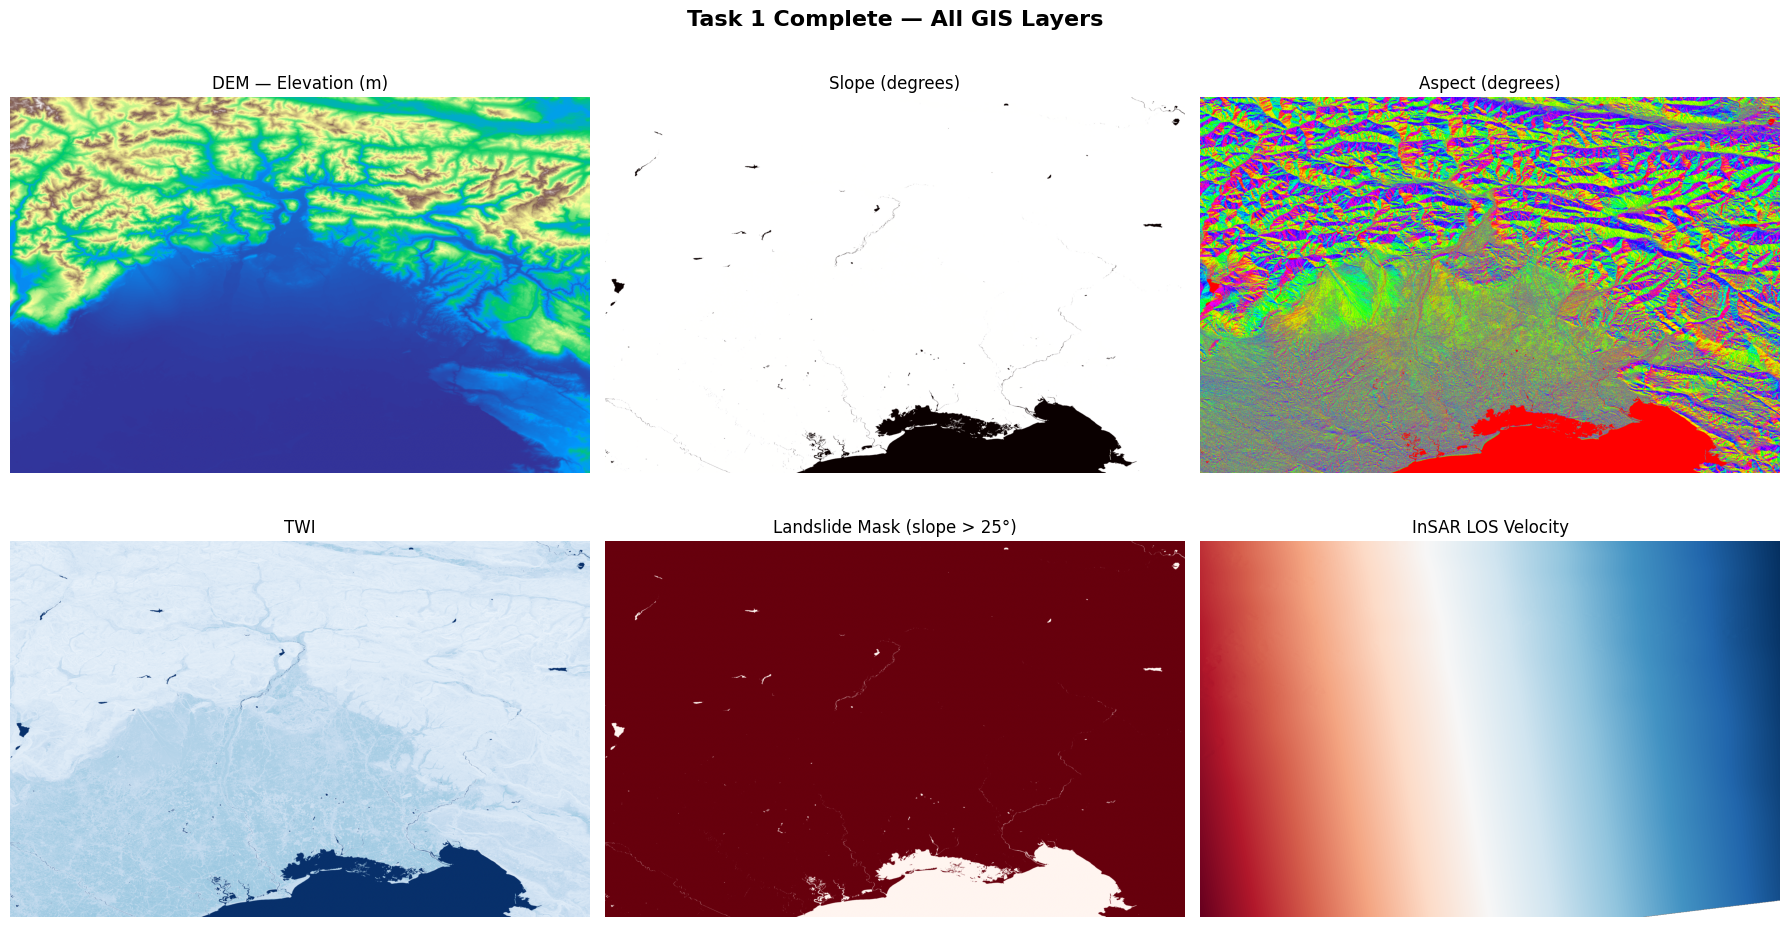

Task 1 visualisation saved!


In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].imshow(dem_array, cmap='terrain')
axes[0,0].set_title('DEM — Elevation (m)')
axes[0,0].axis('off')

axes[0,1].imshow(slope, cmap='hot')
axes[0,1].set_title('Slope (degrees)')
axes[0,1].axis('off')

axes[0,2].imshow(aspect, cmap='hsv')
axes[0,2].set_title('Aspect (degrees)')
axes[0,2].axis('off')

axes[1,0].imshow(twi, cmap='Blues')
axes[1,0].set_title('TWI')
axes[1,0].axis('off')

axes[1,1].imshow(synthetic_mask, cmap='Reds')
axes[1,1].set_title('Landslide Mask (slope > 25°)')
axes[1,1].axis('off')

# Load and show InSAR velocity
with rasterio.open(f'{OUT_TASK1}/insar_velocity_aligned.tif') as src:
    vel = src.read(1)
axes[1,2].imshow(vel, cmap='RdBu_r')
axes[1,2].set_title('InSAR LOS Velocity')
axes[1,2].axis('off')

plt.suptitle('Task 1 Complete — All GIS Layers', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_TASK1}/task1_complete.png', dpi=150)
plt.show()
print('Task 1 visualisation saved!')